In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/payaldhokane/stress-analysis-in-social-media-dataset/dreaddit-train.csv
/kaggle/input/datasets/payaldhokane/stress-analysis-in-social-media-dataset/dreaddit-test.csv
/kaggle/input/datasets/suchintikasarkar/sentiment-analysis-for-mental-health/Combined Data.csv
/kaggle/input/datasets/nsr51324/sentiment-analysis-for-mental-health/Sentiment Analysis for Mental Health.csv
/kaggle/input/datasets/michellevp/predicting-anxiety-in-mental-health-data/healthanxiety_dataset.csv


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import os
import re
import random
import string
from joblib import dump

import nltk
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from wordcloud import WordCloud

from sklearn.model_selection import train_test_split , GridSearchCV
from sklearn.preprocessing import LabelEncoder, MinMaxScaler, StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, KFold
from sklearn.model_selection import GridSearchCV
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.utils.class_weight import compute_class_weight
from imblearn.over_sampling import RandomOverSampler
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional, GRU
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import pickle
import joblib

import warnings
warnings.filterwarnings('ignore')

2026-05-23 00:11:26.803290: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779495087.046326      16 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779495087.116736      16 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779495087.681534      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779495087.681584      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779495087.681587      16 computation_placer.cc:177] computation placer alr

# **Data collection**

In [3]:
df1 = pd.read_csv("/kaggle/input/datasets/nsr51324/sentiment-analysis-for-mental-health/Sentiment Analysis for Mental Health.csv")
df1

,Unnamed: 0,statement,status
0,0,oh my gosh,Anxiety
1,1,"trouble sleeping, confused mind, restless hear...",Anxiety
2,2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety
3,3,I've shifted my focus to something else but I'...,Anxiety
4,4,"I'm restless and restless, it's been a month n...",Anxiety
...,...,...,...
27634,27634,Well I guess it was my second. Last week we se...,Normal
27635,27635,I'm leaning more toward not responding but I h...,Normal
27636,27636,Things between us were amicable until that poi...,Normal
27637,27637,My girlfriend does have PTSD. She said that sh...,Stress


In [4]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27639 entries, 0 to 27638
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  27639 non-null  int64 
 1   statement   27629 non-null  object
 2   status      27639 non-null  object
dtypes: int64(1), object(2)
memory usage: 647.9+ KB


In [5]:
df1.duplicated().sum()

np.int64(0)

In [6]:
df1.isnull().sum()

Unnamed: 0     0
statement     10
status         0
dtype: int64

In [7]:
df1[df1['statement'].isna()]

,Unnamed: 0,statement,status
293,293,NaN,Anxiety
572,572,NaN,Anxiety
595,595,NaN,Anxiety
1539,1539,NaN,Normal
2448,2448,NaN,Normal
2470,2470,NaN,Normal
2753,2753,NaN,Normal
4331,4331,NaN,Normal
5878,5878,NaN,Normal
6513,6513,NaN,Normal


In [8]:
df1['status'].value_counts()

status
Depression    10371
Suicidal       9993
Normal         6383
Anxiety         733
Stress          159
Name: count, dtype: int64

In [9]:
df1[df1['status'] == 'Normal']

,Unnamed: 0,statement,status
733,733,"Gr gr dreaming of ex crush to be my game, God",Normal
734,734,wkwkwk what a joke,Normal
735,735,Leaves are also standby in front of the PC ......,Normal
736,736,Thank God even though it's just a ride through,Normal
737,737,wedding teaser concept using the song day6 - o...,Normal
...,...,...,...
27632,27632,"I am the person you go to to get stuff done, o...",Normal
27633,27633,and how that would intersect with a potential ...,Normal
27634,27634,Well I guess it was my second. Last week we se...,Normal
27635,27635,I'm leaning more toward not responding but I h...,Normal


In [10]:
df2 = pd.read_csv("/kaggle/input/datasets/suchintikasarkar/sentiment-analysis-for-mental-health/Combined Data.csv")
df2

,Unnamed: 0,statement,status
0,0,oh my gosh,Anxiety
1,1,"trouble sleeping, confused mind, restless hear...",Anxiety
2,2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety
3,3,I've shifted my focus to something else but I'...,Anxiety
4,4,"I'm restless and restless, it's been a month n...",Anxiety
...,...,...,...
53038,53038,Nobody takes me seriously I’ve (24M) dealt wit...,Anxiety
53039,53039,"selfishness ""I don't feel very good, it's lik...",Anxiety
53040,53040,Is there any way to sleep better? I can't slee...,Anxiety
53041,53041,"Public speaking tips? Hi, all. I have to give ...",Anxiety


In [11]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53043 entries, 0 to 53042
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  53043 non-null  int64 
 1   statement   52681 non-null  object
 2   status      53043 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.2+ MB


In [12]:
df2.duplicated().sum()

np.int64(0)

In [13]:
df2.isnull().sum()

Unnamed: 0      0
statement     362
status          0
dtype: int64

In [14]:
df2['status'].value_counts()

status
Normal                  16351
Depression              15404
Suicidal                10653
Anxiety                  3888
Bipolar                  2877
Stress                   2669
Personality disorder     1201
Name: count, dtype: int64

In [15]:
stress_df = df2[df2['status'] == 'Stress']
stress_df

,Unnamed: 0,statement,status
27346,27346,"He said he had not felt that way before, sugge...",Stress
27348,27348,My mom then hit me with the newspaper and it s...,Stress
27349,27349,"until i met my new boyfriend, he is amazing, h...",Stress
27350,27350,October is Domestic Violence Awareness Month a...,Stress
27351,27351,I think he doesn't want to put in the effort f...,Stress
...,...,...,...
49464,49464,How to fight PCOS with diet and nutrition? PCO...,Stress
49465,49465,Do you ever feel like anxiety and depression a...,Stress
49466,49466,Is it normal to feel a gurgling in your chest ...,Stress
49467,49467,Lets lose the fears \n\nFear is a normal emot...,Stress


In [16]:
anxiety_df = df2[df2['status'] == 'Anxiety']
anxiety_df

,Unnamed: 0,statement,status
0,0,oh my gosh,Anxiety
1,1,"trouble sleeping, confused mind, restless hear...",Anxiety
2,2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety
3,3,I've shifted my focus to something else but I'...,Anxiety
4,4,"I'm restless and restless, it's been a month n...",Anxiety
...,...,...,...
53038,53038,Nobody takes me seriously I’ve (24M) dealt wit...,Anxiety
53039,53039,"selfishness ""I don't feel very good, it's lik...",Anxiety
53040,53040,Is there any way to sleep better? I can't slee...,Anxiety
53041,53041,"Public speaking tips? Hi, all. I have to give ...",Anxiety


In [17]:
normal_df = df2[df2['status'] == 'Normal'].sample(6000)
normal_df

,Unnamed: 0,statement,status
5950,5950,How many people do I want to do this? He's the...,Normal
33035,33035,"oh, yes. we all took lots of pictures.",Normal
4368,4368,Teteh teteh at the puskeswan cimahi really bit...,Normal
33074,33074,so am i.,Normal
31360,31360,"no, i always back up my files.",Normal
...,...,...,...
30981,30981,i got divorced two years ago.,Normal
1197,1197,Overthinking in the morning. Very delicious br...,Normal
2592,2592,"So you're dating just for prestige, huh? It's ...",Normal
42610,42610,ourcitylight that wa so sudden,Normal


In [18]:
df3 = pd.read_csv("/kaggle/input/datasets/michellevp/predicting-anxiety-in-mental-health-data/healthanxiety_dataset.csv")
df3

,subreddit,author,date,post,automated_readability_index,coleman_liau_index,flesch_kincaid_grade_level,flesch_reading_ease,gulpease_index,gunning_fog_index,...,tfidf_wish,tfidf_without,tfidf_wonder,tfidf_work,tfidf_worri,tfidf_wors,tfidf_would,tfidf_wrong,tfidf_x200b,tfidf_year
0,healthanxiety,Nomis176,1/1/2018,"Final doctor appointment tomorrow, tired of co...",9.137909,7.282428,8.616061,72.474091,61.090909,11.345455,...,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.055919
1,healthanxiety,psychstudent317,1/1/2018,Anyone have bone or muscle pain that was stres...,4.399892,7.131386,3.665806,87.185376,74.161290,5.423656,...,0.000000,0.000000,0.0,0.000000,0.290466,0.0,0.000000,0.000000,0.000000,0.000000
2,healthanxiety,bulk_barn,1/1/2018,Listening to your body? I'm curious how those ...,3.590660,4.930895,4.605802,85.640967,72.584906,7.564151,...,0.000000,0.000000,0.0,0.110757,0.000000,0.0,0.000000,0.332673,0.000000,0.000000
3,healthanxiety,AutoModerator,1/1/2018,Weekly /r/HealthAnxiety Challenge - Exercise A...,4.515682,7.033342,5.059091,78.383636,72.863636,8.945455,...,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000
4,healthanxiety,parthkhurana7,1/1/2018,This is killing me So i had a bacterial stomac...,3.034388,5.356252,3.977494,85.306958,76.721519,7.757637,...,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1962,healthanxiety,357fallingspring,4/20/2019,I’ve been just kind of denying or ignoring thi...,1.665848,3.353629,3.751530,88.320636,78.488372,7.503060,...,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.114765
1963,healthanxiety,Emgetic,4/20/2019,Body Pulling after waking up. I woke up this m...,3.562734,5.205989,4.865959,82.538899,73.159292,7.146116,...,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000
1964,healthanxiety,NoIdeaWhatImDoingL0L,4/20/2019,mole on my back left my mind racing link to pi...,6.908388,8.158499,5.237088,84.528745,64.714286,7.385348,...,0.198151,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.418758,0.000000
1965,healthanxiety,firstofsept,4/20/2019,another health scare so about an hour ago? i w...,2.522109,3.799322,3.230125,94.702375,75.171875,6.995000,...,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.139798,0.000000,0.000000,0.126730


In [19]:
df3['subreddit'].value_counts()

subreddit
healthanxiety    1967
Name: count, dtype: int64

In [20]:
df3 = df3[['subreddit', 'post']]
df3

,subreddit,post
0,healthanxiety,"Final doctor appointment tomorrow, tired of co..."
1,healthanxiety,Anyone have bone or muscle pain that was stres...
2,healthanxiety,Listening to your body? I'm curious how those ...
3,healthanxiety,Weekly /r/HealthAnxiety Challenge - Exercise A...
4,healthanxiety,This is killing me So i had a bacterial stomac...
...,...,...
1962,healthanxiety,I’ve been just kind of denying or ignoring thi...
1963,healthanxiety,Body Pulling after waking up. I woke up this m...
1964,healthanxiety,mole on my back left my mind racing link to pi...
1965,healthanxiety,another health scare so about an hour ago? i w...


In [21]:
df3 = df3.rename(columns={
    "subreddit": "status",
    "post": "statement"
})

In [22]:
df3['status'] = df3['status'].replace('healthanxiety', 'Anxiety')

In [23]:
df3

,status,statement
0,Anxiety,"Final doctor appointment tomorrow, tired of co..."
1,Anxiety,Anyone have bone or muscle pain that was stres...
2,Anxiety,Listening to your body? I'm curious how those ...
3,Anxiety,Weekly /r/HealthAnxiety Challenge - Exercise A...
4,Anxiety,This is killing me So i had a bacterial stomac...
...,...,...
1962,Anxiety,I’ve been just kind of denying or ignoring thi...
1963,Anxiety,Body Pulling after waking up. I woke up this m...
1964,Anxiety,mole on my back left my mind racing link to pi...
1965,Anxiety,another health scare so about an hour ago? i w...


In [24]:
data_train = pd.read_csv("/kaggle/input/datasets/payaldhokane/stress-analysis-in-social-media-dataset/dreaddit-train.csv")
data_test = pd.read_csv("/kaggle/input/datasets/payaldhokane/stress-analysis-in-social-media-dataset/dreaddit-test.csv")

In [25]:
df4 = pd.concat([data_train, data_test], ignore_index=True)

In [26]:
df4['subreddit'].value_counts()

subreddit
ptsd                711
relationships       694
anxiety             650
domesticviolence    388
assistance          355
survivorsofabuse    315
homeless            220
almosthomeless       99
stress               78
food_pantry          43
Name: count, dtype: int64

In [27]:
df4 = df4[['subreddit', 'text']]
df4

,subreddit,text
0,ptsd,"He said he had not felt that way before, sugge..."
1,assistance,"Hey there r/assistance, Not sure if this is th..."
2,ptsd,My mom then hit me with the newspaper and it s...
3,relationships,"until i met my new boyfriend, he is amazing, h..."
4,survivorsofabuse,October is Domestic Violence Awareness Month a...
...,...,...
3548,ptsd,i have horrible vivid nightmares every night. ...
3549,relationships,Also I can't think about both of them without ...
3550,relationships,"Furthermore, I told him before we got really s..."
3551,assistance,Here's the link to my amazon wish list where t...


In [28]:
df4 = df4.rename(columns={
    "subreddit": "status",
    "text": "statement"
})

In [29]:
df4['status'] = df4['status'].replace('anxiety', 'Anxiety')

In [30]:
df4['status'] = df4['status'].replace('stress', 'Stress')

In [31]:
df4_anxiety = df4[df4['status'] == 'Anxiety']
df4_anxiety

,status,statement
7,Anxiety,It cleared up and I was okay but. On Monday ...
10,Anxiety,Next week I’ll be flying for our family vacati...
11,Anxiety,Everything sets me off and I'm almost having a...
12,Anxiety,I’ve been taking 12.5 mgs zoloft for about 6 m...
14,Anxiety,These past couple of months have been the wors...
...,...,...
3523,Anxiety,-What are you gonna do with that strange looki...
3524,Anxiety,"I don't know why this happened, but I use to h..."
3528,Anxiety,aaaa sorry I feel so dumb for messing up like ...
3529,Anxiety,All I have from them is a roof over a head and...


In [32]:
df4_stress =  df4[df4['status'] == 'Stress']
df4_stress

,status,statement
31,Stress,I feel like I'm trying to reason my situation ...
70,Stress,I'm 24 and have massive amounts of stress goin...
94,Stress,The simplest breathing technique can help you ...
127,Stress,I'm a senior and I'm starting to go through t...
249,Stress,But three days ago they put his dad on the mor...
...,...,...
3431,Stress,she then tells me i’m self centered and i’m a ...
3432,Stress,"i’m 15, i don’t want to be anywhere near my da..."
3433,Stress,she asks me if i want tea and to watch tv with...
3446,Stress,I have panic attack after panic attack and I t...


# **Merge data**

In [33]:
df = pd.concat([df1, df3,stress_df, anxiety_df, normal_df , df4_anxiety, df4_stress], ignore_index=True)
df

,Unnamed: 0,statement,status
0,0.0,oh my gosh,Anxiety
1,1.0,"trouble sleeping, confused mind, restless hear...",Anxiety
2,2.0,"All wrong, back off dear, forward doubt. Stay ...",Anxiety
3,3.0,I've shifted my focus to something else but I'...,Anxiety
4,4.0,"I'm restless and restless, it's been a month n...",Anxiety
...,...,...,...
42886,NaN,she then tells me i’m self centered and i’m a ...,Stress
42887,NaN,"i’m 15, i don’t want to be anywhere near my da...",Stress
42888,NaN,she asks me if i want tea and to watch tv with...,Stress
42889,NaN,I have panic attack after panic attack and I t...,Stress


# **Data Cleaning**

In [34]:
df.duplicated().sum()

np.int64(3245)

In [35]:
df.drop_duplicates(inplace=True)

In [36]:
df.isnull().sum()

Unnamed: 0    2693
statement      136
status           0
dtype: int64

In [37]:
df['status'].value_counts()

status
Depression    10371
Normal        10028
Suicidal       9993
Anxiety        6507
Stress         2747
Name: count, dtype: int64

In [38]:
df.drop('Unnamed: 0', inplace=True , axis=1)

In [39]:
df.dropna(subset=['statement'], inplace=True)

In [40]:
df.isnull().sum()

statement    0
status       0
dtype: int64

In [41]:
df

,statement,status
0,oh my gosh,Anxiety
1,"trouble sleeping, confused mind, restless hear...",Anxiety
2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety
3,I've shifted my focus to something else but I'...,Anxiety
4,"I'm restless and restless, it's been a month n...",Anxiety
...,...,...
42886,she then tells me i’m self centered and i’m a ...,Stress
42887,"i’m 15, i don’t want to be anywhere near my da...",Stress
42888,she asks me if i want tea and to watch tv with...,Stress
42889,I have panic attack after panic attack and I t...,Stress


In [42]:
df.describe(include='O')

,statement,status
count,39510,39510
unique,36444,5
top,#NAME?,Depression
freq,14,10371


In [43]:
df = df[df['statement'] != '#NAME?']

In [44]:
df.describe(include='O')

,statement,status
count,39496,39496
unique,36443,5
top,ni-ki best boy,Depression
freq,11,10363


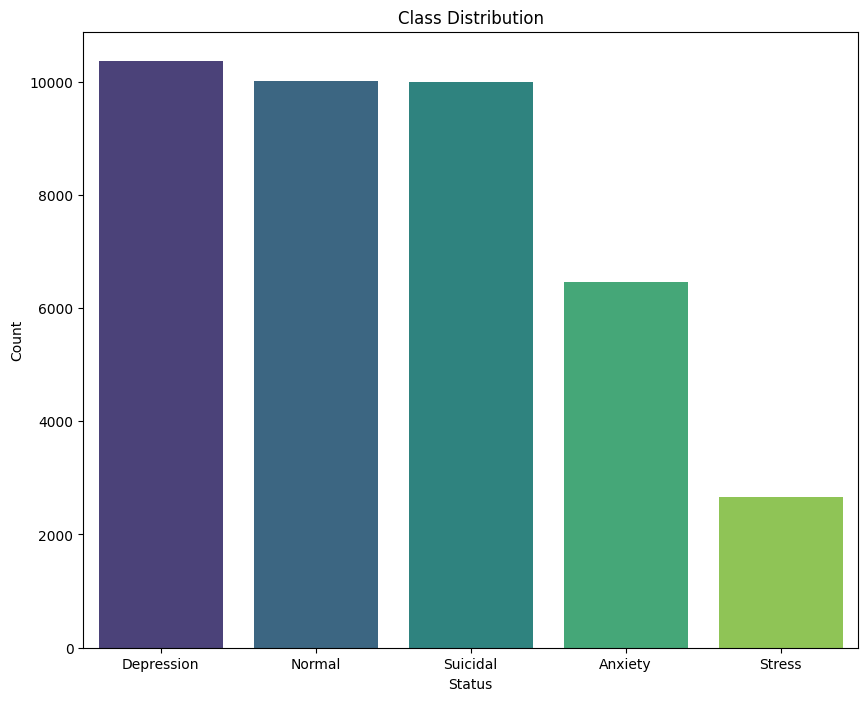

In [45]:
counts = df['status'].value_counts()

plt.figure(figsize=(10,8))
sns.barplot(x=counts.index, y=counts.values, palette='viridis')
plt.title('Class Distribution')
plt.xlabel("Status")
plt.ylabel('Count')
plt.show()

In [46]:
df['statement_length'] = df['statement'].apply(len)
df['num_words'] = df['statement'].apply(lambda x: len(x.split()))
df['vocabulary_size'] = df['statement'].apply(lambda x: len(set(x.split())))
df.head()

,statement,status,statement_length,num_words,vocabulary_size
0,oh my gosh,Anxiety,10,3,3
1,"trouble sleeping, confused mind, restless hear...",Anxiety,64,10,10
2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety,78,14,13
3,I've shifted my focus to something else but I'...,Anxiety,61,11,11
4,"I'm restless and restless, it's been a month n...",Anxiety,72,14,14


In [47]:
num_feature = []

for feature in df.columns:
    if df[feature].dtype != 'O':
        num_feature.append(feature)

num_feature

['statement_length', 'num_words', 'vocabulary_size']

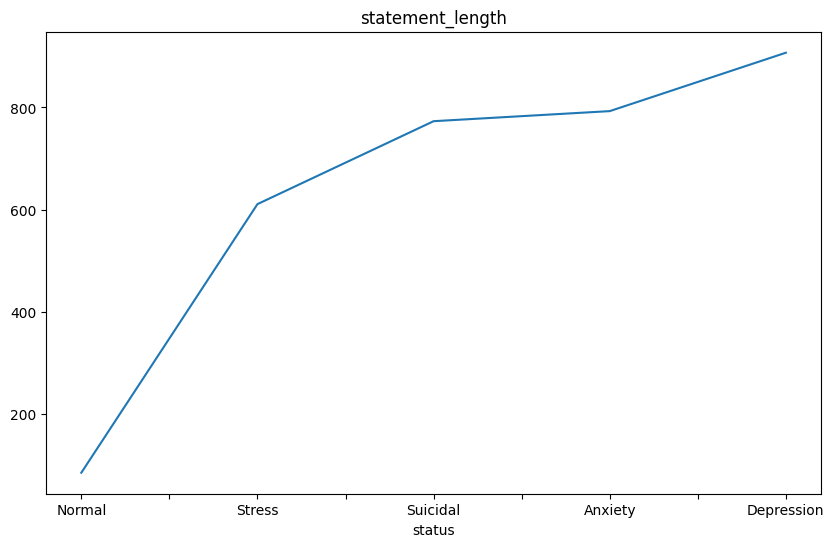

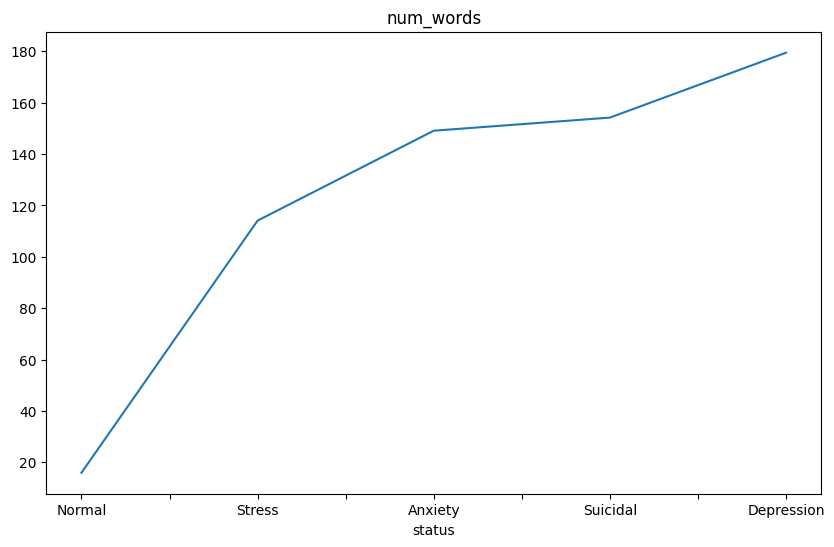

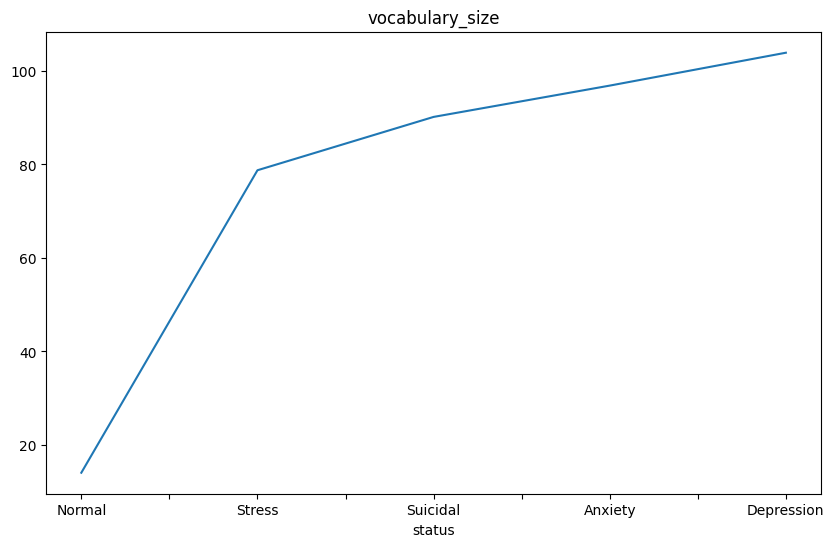

In [48]:
for feature in num_feature:
    plt.figure(figsize= (10,6))
    df.groupby('status')[feature].mean().sort_values().plot()
    plt.title(feature)
    plt.show()

# **NLP preprocessing**

In [49]:
df['statement']= df['statement'].str.lower()

In [50]:
chatwords = {
    "ain't": "is not",
    "isn t": "is not",
    "aren't": "are not",
    "can't": "cannot",
    "couldn't": "could not",
    "didn't": "did not",
    "doesn't": "does not",
    "don't": "do not",
    "hadn't": "had not",
    "hasn't": "has not",
    "haven't": "have not",
    "he's": "he is",
    "she's": "she is",
    "it's": "it is",
    "that's": "that is",
    "there's": "there is",
    "what's": "what is",
    "who's": "who is",
    "I'm": "i am",
    "i'm": "i am",
    "I'll": "i will",
    "i'll": "i will",
    "I'd": "i would",
    "i'd": "i would",
    "I've": "i have",
    "i've": "i have",
    "i ve": "i have",
    "isn't": "is not",
    "let's": "let us",
    "shouldn't": "should not",
    "won't": "will not",
    "wouldn't": "would not",
    "wasn't": "was not",
    "weren't": "were not",
    "you're": "you are",
    "you've": "you have",
    "you'll": "you will",
    "they're": "they are",
    "they've": "they have",
    "they'll": "they will",
    "we're": "we are",
    "we've": "we have",
    "we'll": "we will",
    "omg": "oh my god",
    "lol": "laughing out loud",
    "lmao": "laughing my ass off",
    "rofl": "rolling on the floor laughing",
    "idk": "i do not know",
    "imo": "in my opinion",
    "imho": "in my humble opinion",
    "btw": "by the way",
    "thx": "thanks",
    "ty": "thank you",
    "pls": "please",
    "plz": "please",
    "u": "you",
    "ur": "your",
    "r": "are",
    "ya": "you",
    "wanna": "want to",
    "gonna": "going to",
    "gotta": "got to",
    "kinda": "kind of",
    "sorta": "sort of",
    "lemme": "let me",
    "gimme": "give me",
    "cuz": "because",
    "bc": "because",
    "bcoz": "because",
    "bcz": "because",
    "b4": "before",
    "gr8": "great",
    "l8r": "later",
    "nvm": "never mind",
    "tho": "though",
    "thx": "thanks",
    "xoxo": "hugs and kisses",
    "tbh": "to be honest",
    "afaik": "as far as i know",
    "asap": "as soon as possible",
    "bff": "best friend forever",
    "brb": "be right back",
    "fyi": "for your information",
    "jk": "just kidding",
    "np": "no problem",
    "sry": "sorry",
    "smh": "shaking my head",
    "ttyl": "talk to you later",
    "wyd": "what are you doing",
    "wtf": "what the fuck",
    "wth": "what the hell",
    "idc": "i do not care",
    "ikr": "i know right",
    "hbu": "how about you",
    "ily": "i love you",
    "luv": "love",
    "n": "and",
    "coz": "because",
    "bday": "birthday",
    "msg": "message",
}

In [51]:
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [52]:
from nltk.stem import WordNetLemmatizer
import nltk

nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('punkt')

lemmatizer = WordNetLemmatizer()

[nltk_data] Downloading package wordnet to /usr/share/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /usr/share/nltk_data...
[nltk_data] Downloading package punkt to /usr/share/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [53]:
def handle_negation(text):
    words = text.split()
    result = []
    
    negation_words = {"not", "no", "never"}
    negate = False
    
    for w in words:
        if w in negation_words:
            negate = True
            result.append(w)
        elif negate:
            result.append("not " + w)
            negate = False
        else:
            result.append(w)
    
    return " ".join(result)

In [54]:
def clean_text_v3(text):

    text = str(text).lower()

    text = re.sub(r'https?:\/\/\S+', '', text)
    text = re.sub(r'www\.\S+', '', text)
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'@[A-Za-z0-9_]+', '', text)
    text = re.sub(r'#', '', text)
    text = re.sub(r'\s+', ' ', text).strip()

    for word, replacement in chatwords.items():
        text = re.sub(r'\b' + re.escape(word) + r'\b', replacement, text)

    text = handle_negation(text)

    words = text.split()
    words = [lemmatizer.lemmatize(w) for w in words]

    return ' '.join(words)

In [55]:
df['clean_text_v2'] = df['statement'].apply(clean_text_v3)

In [56]:
df[['statement', 'clean_text_v2']].sample(20)

,statement,clean_text_v2
29159,"help, idk if this is the right reddit, but i d...","help, i do not not know if this is the right r..."
1319,"if you arrive in indonesia, how much will it be?","if you arrive in indonesia, how much will it be?"
11146,"i cut my arm multiple times, nothing too deep ...","i cut my arm multiple times, nothing too deep ..."
22455,two years ago i moved to the us for college. i...,two year ago i moved to the u for college. i a...
21652,"think about, when i am happy, it is just chemi...","think about, when i am happy, it is just chemi..."
18344,long story short i was feeling like relapsing ...,long story short i wa feeling like relapsing a...
23692,i am so fucking tired of this my life sucks i ...,i am so fucking tired of this my life suck i g...
23709,i am tired of trying for other people. i do no...,i am tired of trying for other people. i do no...
23703,there is this future i dream of that id really...,there is this future i dream of that id really...
11533,"so, here is the problem; i know too much, i do...","so, here is the problem; i know too much, i do..."


In [57]:
df['status'].value_counts()

status
Depression    10363
Normal        10019
Suicidal       9992
Anxiety        6459
Stress         2663
Name: count, dtype: int64

# **StopWords**

In [58]:
# Tokenization and Stopwords Removal
stop_words = set(stopwords.words('english'))

def remove_stopwords(text):
    tokens = word_tokenize(text)
    tokens = [word for word in tokens if word not in stop_words]
    return ' '.join(tokens)

df['clean_text_v2'] = df['clean_text_v2'].apply(lambda x: remove_stopwords(x))

# **Tokenization**

In [59]:
df['tokens'] = df['clean_text_v2'].apply(word_tokenize)
df.head()

,statement,status,statement_length,num_words,vocabulary_size,clean_text_v2,tokens
0,oh my gosh,Anxiety,10,3,3,oh gosh,"[oh, gosh]"
1,"trouble sleeping, confused mind, restless hear...",Anxiety,64,10,10,"trouble sleeping , confused mind , restless he...","[trouble, sleeping, ,, confused, mind, ,, rest..."
2,"all wrong, back off dear, forward doubt. stay ...",Anxiety,78,14,13,"wrong , back dear , forward doubt . stay restl...","[wrong, ,, back, dear, ,, forward, doubt, ., s..."
3,i've shifted my focus to something else but i'...,Anxiety,61,11,11,shifted focus something else still worried,"[shifted, focus, something, else, still, worried]"
4,"i'm restless and restless, it's been a month n...",Anxiety,72,14,14,"restless restless , month , boy . mean ?","[restless, restless, ,, month, ,, boy, ., mean..."


# **Lemmatization**

In [60]:
from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()

def lemmatize_tokens(tokens):
    return ' '.join(lemmatizer.lemmatize(str(token)) for token in tokens)

# Apply to dataframe
df['tokens_lemmad'] = df['tokens'].apply(lemmatize_tokens)

df.head()

,statement,status,statement_length,num_words,vocabulary_size,clean_text_v2,tokens,tokens_lemmad
0,oh my gosh,Anxiety,10,3,3,oh gosh,"[oh, gosh]",oh gosh
1,"trouble sleeping, confused mind, restless hear...",Anxiety,64,10,10,"trouble sleeping , confused mind , restless he...","[trouble, sleeping, ,, confused, mind, ,, rest...","trouble sleeping , confused mind , restless he..."
2,"all wrong, back off dear, forward doubt. stay ...",Anxiety,78,14,13,"wrong , back dear , forward doubt . stay restl...","[wrong, ,, back, dear, ,, forward, doubt, ., s...","wrong , back dear , forward doubt . stay restl..."
3,i've shifted my focus to something else but i'...,Anxiety,61,11,11,shifted focus something else still worried,"[shifted, focus, something, else, still, worried]",shifted focus something else still worried
4,"i'm restless and restless, it's been a month n...",Anxiety,72,14,14,"restless restless , month , boy . mean ?","[restless, restless, ,, month, ,, boy, ., mean...","restless restless , month , boy . mean ?"


# **Encoding**

In [61]:
label_encoder = LabelEncoder()

df['status'] = label_encoder.fit_transform(df['status'])
df.head()

,statement,status,statement_length,num_words,vocabulary_size,clean_text_v2,tokens,tokens_lemmad
0,oh my gosh,0,10,3,3,oh gosh,"[oh, gosh]",oh gosh
1,"trouble sleeping, confused mind, restless hear...",0,64,10,10,"trouble sleeping , confused mind , restless he...","[trouble, sleeping, ,, confused, mind, ,, rest...","trouble sleeping , confused mind , restless he..."
2,"all wrong, back off dear, forward doubt. stay ...",0,78,14,13,"wrong , back dear , forward doubt . stay restl...","[wrong, ,, back, dear, ,, forward, doubt, ., s...","wrong , back dear , forward doubt . stay restl..."
3,i've shifted my focus to something else but i'...,0,61,11,11,shifted focus something else still worried,"[shifted, focus, something, else, still, worried]",shifted focus something else still worried
4,"i'm restless and restless, it's been a month n...",0,72,14,14,"restless restless , month , boy . mean ?","[restless, restless, ,, month, ,, boy, ., mean...","restless restless , month , boy . mean ?"


In [62]:
df

,statement,status,statement_length,num_words,vocabulary_size,clean_text_v2,tokens,tokens_lemmad
0,oh my gosh,0,10,3,3,oh gosh,"[oh, gosh]",oh gosh
1,"trouble sleeping, confused mind, restless hear...",0,64,10,10,"trouble sleeping , confused mind , restless he...","[trouble, sleeping, ,, confused, mind, ,, rest...","trouble sleeping , confused mind , restless he..."
2,"all wrong, back off dear, forward doubt. stay ...",0,78,14,13,"wrong , back dear , forward doubt . stay restl...","[wrong, ,, back, dear, ,, forward, doubt, ., s...","wrong , back dear , forward doubt . stay restl..."
3,i've shifted my focus to something else but i'...,0,61,11,11,shifted focus something else still worried,"[shifted, focus, something, else, still, worried]",shifted focus something else still worried
4,"i'm restless and restless, it's been a month n...",0,72,14,14,"restless restless , month , boy . mean ?","[restless, restless, ,, month, ,, boy, ., mean...","restless restless , month , boy . mean ?"
...,...,...,...,...,...,...,...,...
42886,she then tells me i’m self centered and i’m a ...,3,400,80,62,tell ’ self centered ’ fuck ’ fucking sister ....,"[tell, ’, self, centered, ’, fuck, ’, fucking,...",tell ’ self centered ’ fuck ’ fucking sister ....
42887,"i’m 15, i don’t want to be anywhere near my da...",3,365,77,63,"’ 15 , ’ want anywhere near dad shit ’ done ha...","[’, 15, ,, ’, want, anywhere, near, dad, shit,...","’ 15 , ’ want anywhere near dad shit ’ done ha..."
42888,she asks me if i want tea and to watch tv with...,3,254,50,40,asks want tea watch tv . probably sound confus...,"[asks, want, tea, watch, tv, ., probably, soun...",asks want tea watch tv . probably sound confus...
42889,i have panic attack after panic attack and i t...,3,661,119,84,panic attack panic attack truly know anymore ....,"[panic, attack, panic, attack, truly, know, an...",panic attack panic attack truly know anymore ....


# **Spliting**

In [63]:
x = df['tokens_lemmad']
y = df['status']

In [64]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42 ,stratify=y)

# **Vectorization**

In [65]:
vectorizer = TfidfVectorizer(
    ngram_range=(1,2),
    max_features=12000,
)

X_train_tfidf = vectorizer.fit_transform(x_train)
X_test_tfidf = vectorizer.transform(x_test)

# **Build Model**

In [66]:
# Model Training with Hyperparameter Tuning
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100]
}

model = LogisticRegression(class_weight='balanced',max_iter=1000)
grid_search = GridSearchCV(model, param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train_tfidf, y_train)

best_model = grid_search.best_estimator_

# **Evaluation & Metrics**

In [67]:
y_pred = best_model.predict(X_test_tfidf)

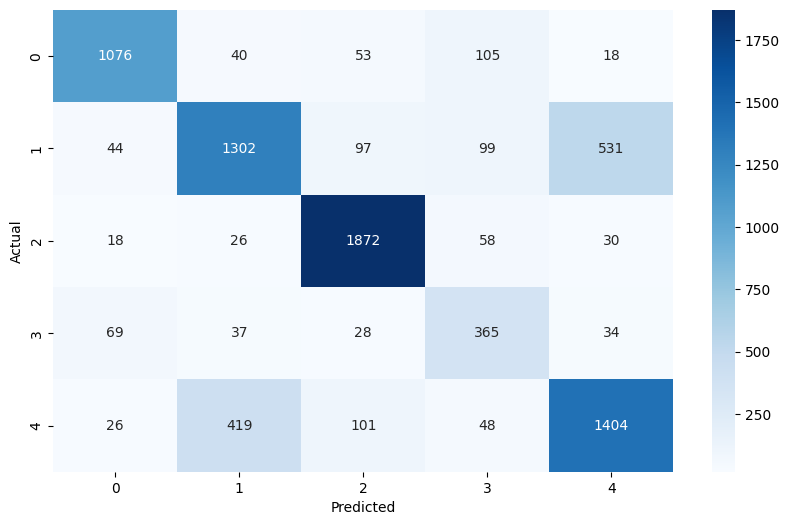

In [68]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [69]:
print("Best Parameters:")
print(grid_search.best_params_)

print("Accuracy Score:")
print(accuracy_score(y_test, y_pred))

print("Classification Report:")
print(classification_report(y_test, y_pred))

Best Parameters:
{'C': 1}
Accuracy Score:
0.7618987341772152
Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.83      0.85      1292
           1       0.71      0.63      0.67      2073
           2       0.87      0.93      0.90      2004
           3       0.54      0.68      0.60       533
           4       0.70      0.70      0.70      1998

    accuracy                           0.76      7900
   macro avg       0.74      0.76      0.75      7900
weighted avg       0.76      0.76      0.76      7900



In [70]:
label_map = dict(zip(
    label_encoder.transform(label_encoder.classes_),
    label_encoder.classes_
))

In [71]:
os.makedirs("models/logistic", exist_ok=True)

dump(best_model, "models/logistic/model.pkl")
dump(label_map, "models/logistic/vectorizer.pkl")
dump(label_encoder, "models/logistic/label_encoder.pkl")

['models/logistic/label_encoder.pkl']

# **Build Model 2**

In [72]:
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100]
}

model = LinearSVC(class_weight='balanced')

grid_search = GridSearchCV(model,param_grid,cv=5,scoring='accuracy')

grid_search.fit(X_train_tfidf, y_train)
best_model = grid_search.best_estimator_

In [73]:
y_pred = best_model.predict(X_test_tfidf)

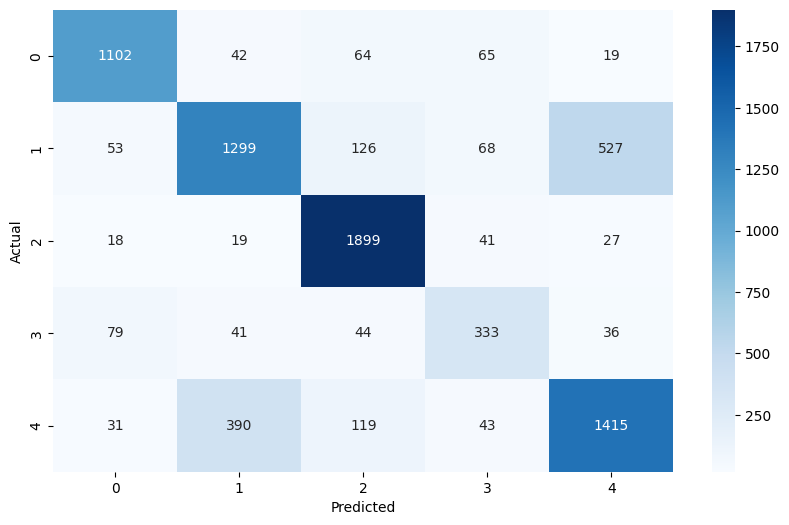

In [74]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [75]:
print("Best Parameters:")
print(grid_search.best_params_)

print("Accuracy Score:")
print(accuracy_score(y_test, y_pred))

print("Classification Report:")
print(classification_report(y_test, y_pred))

Best Parameters:
{'C': 0.1}
Accuracy Score:
0.7655696202531646
Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.85      0.86      1292
           1       0.73      0.63      0.67      2073
           2       0.84      0.95      0.89      2004
           3       0.61      0.62      0.61       533
           4       0.70      0.71      0.70      1998

    accuracy                           0.77      7900
   macro avg       0.75      0.75      0.75      7900
weighted avg       0.76      0.77      0.76      7900



In [76]:
os.makedirs("models/SVC", exist_ok=True)

dump(best_model, "models/SVC/model.pkl")
dump(label_map, "models/SVC/vectorizer.pkl")
dump(label_encoder, "models/SVC/label_encoder.pkl")

['models/SVC/label_encoder.pkl']